# Lab 4: Modelowanie statystyczne — Football Players

## Cele
- Zbudować model regresji liniowej do przewidywania **wartości rynkowej** zawodnika
- Zbudować model regresji logistycznej do **klasyfikacji pozycji** (napastnik vs obrońca)
- Policzyć podstawowe metryki jakości (MAE, RMSE, R², accuracy, ROC AUC)
- Porównać modele z regularyzacją (Ridge, Lasso)
- Zbadać wpływ progu decyzyjnego na precision/recall

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Wczytanie i przygotowanie danych

In [ ]:
DATA_DIR = Path("data/13")

profiles_df = pd.read_csv(DATA_DIR / "all_player_profiles.csv")
stats_df = pd.read_csv(DATA_DIR / "all_player_stats.csv")

df = profiles_df.merge(stats_df, on=["player_id", "league"], how="inner")

# Filtrujemy zawodnikow z co najmniej 600 minut
df = df[df["minutes_played"] >= 600].reset_index(drop=True)

# Statystyki per 90 minut
per90_cols = [
    "goals", "assists", "tackles", "interceptions", "saves",
    "total_shots", "shots_on_target", "expected_goals", "expected_assists",
]
for col in per90_cols:
    df[f"{col}_per90"] = df[col] * 90 / df["minutes_played"]

print(f"Zawodnicy po filtrze: {len(df)}")
print(f"Pozycje: {df['position'].value_counts().to_dict()}")
df.head()

Zawodnicy po filtrze: 2580
Pozycje: {'M': 1015, 'D': 900, 'F': 469, 'G': 196}


,player_id,name,league,position,market_value,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves,goals_per90,assists_per90,tackles_per90,interceptions_per90,saves_per90,total_shots_per90,shots_on_target_per90,expected_goals_per90,expected_assists_per90
0,804508,Viktor Gyökeres,Premier League,F,61000000.0,30,24,1997,12,0,10.3733,1.773005,6.573333,47,18,5,0,6,1,0,0.540811,0.000000,0.270406,0.045068,0.0,2.118177,0.811217,0.467500,0.079905
1,934235,Bukayo Saka,Premier League,F,126000000.0,27,22,2001,6,3,6.9941,5.761951,7.214815,63,26,1,0,36,14,0,0.269865,0.134933,1.619190,0.629685,0.0,2.833583,1.169415,0.314577,0.259158
2,922573,Gabriel Martinelli,Premier League,F,42000000.0,26,10,906,1,3,3.3793,0.999809,6.607692,25,10,2,0,10,0,0,0.099338,0.298013,0.993377,0.000000,0.0,2.483444,0.993377,0.335692,0.099319
3,135666,Leandro Trossard,Premier League,F,21000000.0,27,18,1721,5,5,4.8222,2.685569,6.859259,44,11,1,0,25,8,0,0.261476,0.261476,1.307379,0.418361,0.0,2.300988,0.575247,0.252178,0.140442
4,547410,Martin Ødegaard,Premier League,M,71000000.0,20,13,1078,1,5,1.0108,2.924704,6.995000,20,7,0,0,17,7,0,0.083488,0.417440,1.419295,0.584416,0.0,1.669759,0.584416,0.084390,0.244178


## 2. Regresja liniowa — przewidywanie wartości rynkowej

Przewidywanie wartości rynkowej `market_value` na podstawie statystyk meczowych i pozycji.

Próbki: 2573


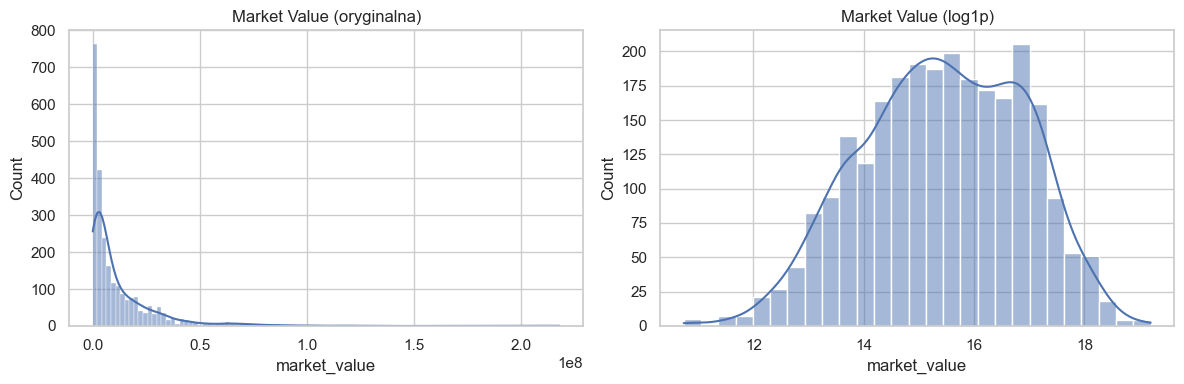

In [5]:
reg_features = [
    "goals_per90", "assists_per90", "expected_goals_per90", "expected_assists_per90",
    "rating", "appearances", "minutes_played",
    "total_shots_per90", "shots_on_target_per90",
    "tackles_per90", "interceptions_per90", "saves_per90",
    "yellow_cards",
]

reg_df = df[reg_features + ["market_value"]].dropna(subset=["market_value"])

X_reg = reg_df[reg_features]
y_reg = np.log1p(reg_df["market_value"])  # log-transform — skośny rozkład

print(f"Próbki: {len(X_reg)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(reg_df["market_value"], kde=True, ax=axes[0])
axes[0].set_title("Market Value (oryginalna)")
sns.histplot(y_reg, kde=True, ax=axes[1])
axes[1].set_title("Market Value (log1p)")
plt.tight_layout()
plt.show()

In [6]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

reg_pipeline.fit(X_train_reg, y_train_reg)

train_pred_reg = reg_pipeline.predict(X_train_reg)
test_pred_reg = reg_pipeline.predict(X_test_reg)

reg_metrics = pd.DataFrame({
    "split": ["train", "test"],
    "MAE": [
        mean_absolute_error(y_train_reg, train_pred_reg),
        mean_absolute_error(y_test_reg, test_pred_reg),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train_reg, train_pred_reg)),
        np.sqrt(mean_squared_error(y_test_reg, test_pred_reg)),
    ],
    "R2": [
        r2_score(y_train_reg, train_pred_reg),
        r2_score(y_test_reg, test_pred_reg),
    ],
})
print("Metryki w przestrzeni log1p:")
reg_metrics

Metryki w przestrzeni log1p:


,split,MAE,RMSE,R2
0,train,1.077670,1.307766,0.212841
1,test,1.043433,1.280113,0.127398


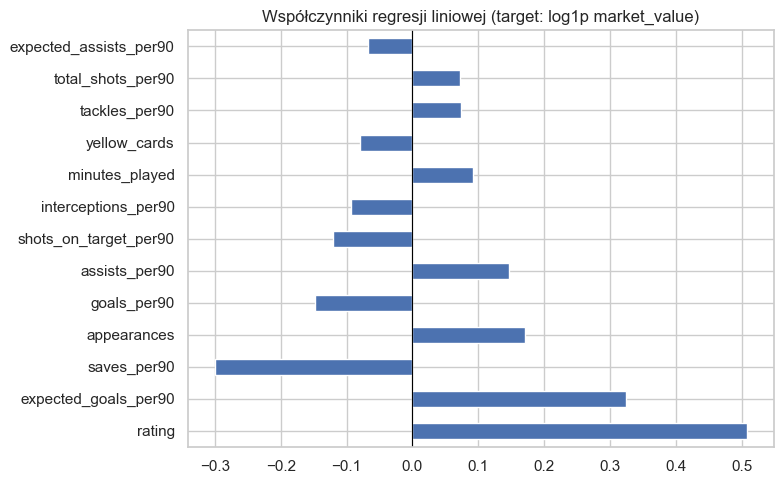

rating                    0.508455
expected_goals_per90      0.324112
saves_per90              -0.300313
appearances               0.171167
goals_per90              -0.148233
assists_per90             0.147171
shots_on_target_per90    -0.120768
interceptions_per90      -0.093415
minutes_played            0.092069
yellow_cards             -0.079041
tackles_per90             0.074367
total_shots_per90         0.071683
expected_assists_per90   -0.067773
dtype: float64

In [7]:
# Współczynniki modelu
coef_reg = pd.Series(
    reg_pipeline.named_steps["model"].coef_,
    index=reg_features,
).sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
coef_reg.plot(kind="barh", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Współczynniki regresji liniowej (target: log1p market_value)")
plt.tight_layout()
plt.show()

coef_reg

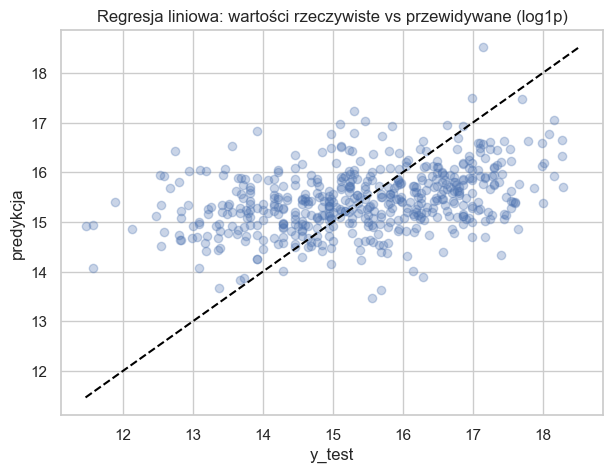

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_reg, test_pred_reg, alpha=0.3)
lims = [min(y_test_reg.min(), test_pred_reg.min()), max(y_test_reg.max(), test_pred_reg.max())]
ax.plot(lims, lims, color="black", linestyle="--")
ax.set_title("Regresja liniowa: wartości rzeczywiste vs przewidywane (log1p)")
ax.set_xlabel("y_test")
ax.set_ylabel("predykcja")
plt.show()

### Pytania do dyskusji
- Które cechy mają największy wpływ na wartość rynkową? Czy to ma sens intuicyjnie?
- Czy różnica R² między train a test wskazuje na przeuczenie czy niedouczenie?
- Dlaczego stosujemy log1p dla `market_value`?

## 3. Regresja logistyczna — klasyfikacja pozycji (napastnik vs obrońca)

Budujemy binarny klasyfikator: **F (forward) = 1** vs **D (defender) = 0**.
Wykluczamy bramkarzy (G) i pomocników (M) — chcemy model skupiony na skrajnie różnych profilach statystycznych.

In [ ]:
cls_df = df[df["position"].isin(["F", "D"])].copy()
cls_df["is_forward"] = (cls_df["position"] == "F").astype(int)

cls_features = [
    "goals_per90", "assists_per90", "expected_goals_per90", "expected_assists_per90",
    "total_shots_per90", "shots_on_target_per90",
    "tackles_per90", "interceptions_per90",
    "rating", "market_value",
]

X_cls = cls_df[cls_features]
y_cls = cls_df["is_forward"]

print(f"Próbki: {len(X_cls)}")
print(f"Rozkład klas: {y_cls.value_counts(normalize=True).round(3).to_dict()}  (0=D, 1=F)")

In [ ]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

cls_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000)),
])

cls_pipeline.fit(X_train_cls, y_train_cls)

train_pred_cls = cls_pipeline.predict(X_train_cls)
test_pred_cls = cls_pipeline.predict(X_test_cls)
test_proba_cls = cls_pipeline.predict_proba(X_test_cls)[:, 1]

cls_metrics = pd.DataFrame({
    "split": ["train", "test"],
    "accuracy": [
        accuracy_score(y_train_cls, train_pred_cls),
        accuracy_score(y_test_cls, test_pred_cls),
    ],
    "roc_auc": [
        roc_auc_score(y_train_cls, cls_pipeline.predict_proba(X_train_cls)[:, 1]),
        roc_auc_score(y_test_cls, test_proba_cls),
    ],
})
cls_metrics

In [ ]:
print(classification_report(y_test_cls, test_pred_cls, target_names=["Defender", "Forward"]))

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_cls, test_pred_cls),
    display_labels=["Defender", "Forward"]
).plot(ax=ax)
ax.set_title("Regresja logistyczna: macierz pomyłek (F vs D)")
plt.show()

In [ ]:
coef_cls = pd.Series(
    cls_pipeline.named_steps["model"].coef_[0],
    index=cls_features,
).sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
coef_cls.plot(kind="barh", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Współczynniki regresji logistycznej (Forward vs Defender)\n>0 = napastnik, <0 = obrońca")
plt.tight_layout()
plt.show()

coef_cls

### Pytania do dyskusji
- Które cechy najsilniej odróżniają napastnika od obrońcy?
- Czy accuracy to dobra metryka dla tego zadania?
- Jak interpretować znak współczynnika w regresji logistycznej?

## 4. Regularyzacja — LinearRegression vs Ridge vs Lasso

Porównujemy trzy modele regresji na tym samym problemie przewidywania wartości rynkowej.

In [ ]:
models_reg = {
    "LinearRegression": LinearRegression(),
    "Ridge(alpha=1.0)": Ridge(alpha=1.0),
    "Ridge(alpha=10.0)": Ridge(alpha=10.0),
    "Lasso(alpha=0.01)": Lasso(alpha=0.01),
    "Lasso(alpha=0.1)": Lasso(alpha=0.1),
}

reg_comparison = []
for name, model in models_reg.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])
    pipe.fit(X_train_reg, y_train_reg)
    reg_comparison.append({
        "model": name,
        "r2_train": r2_score(y_train_reg, pipe.predict(X_train_reg)),
        "r2_test": r2_score(y_test_reg, pipe.predict(X_test_reg)),
        "mae_test": mean_absolute_error(y_test_reg, pipe.predict(X_test_reg)),
    })

pd.DataFrame(reg_comparison).sort_values("r2_test", ascending=False).reset_index(drop=True)

In [ ]:
# Porównanie współczynników — które cechy Lasso wyzeruje?
coef_comparison = pd.DataFrame(index=reg_features)

for name, model in [
    ("Linear", LinearRegression()),
    ("Ridge(10)", Ridge(alpha=10.0)),
    ("Lasso(0.1)", Lasso(alpha=0.1)),
]:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])
    pipe.fit(X_train_reg, y_train_reg)
    coef_comparison[name] = pipe.named_steps["model"].coef_

fig, ax = plt.subplots(figsize=(10, 5))
coef_comparison.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Porównanie współczynników: Linear vs Ridge vs Lasso")
ax.set_xticklabels(reg_features, rotation=45, ha="right")
plt.tight_layout()
plt.show()

coef_comparison

### Pytania do dyskusji
- Które cechy Lasso zeruje? Co to oznacza?
- Czy regularyzacja poprawia R² na zbiorze testowym, czy raczej stabilizuje współczynniki?
- Kiedy wybrać Ridge, a kiedy Lasso?

## 5. Próg decyzyjny — precision vs recall

Zmieniamy próg klasyfikacji dla modelu F vs D i obserwujemy, jak wpływa to na precision i recall.

In [ ]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
threshold_rows = []

for t in thresholds:
    pred = (test_proba_cls >= t).astype(int)
    threshold_rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test_cls, pred),
        "precision": precision_score(y_test_cls, pred, zero_division=0),
        "recall": recall_score(y_test_cls, pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(threshold_df["threshold"], threshold_df["precision"], "o-", label="precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"], "s-", label="recall")
ax.plot(threshold_df["threshold"], threshold_df["accuracy"], "^--", label="accuracy")
ax.set_xlabel("Próg decyzyjny")
ax.set_title("Precision / Recall / Accuracy vs próg (Forward vs Defender)")
ax.legend()
plt.tight_layout()
plt.show()

threshold_df

### Pytania do dyskusji
- Jaki próg wybrać, jeśli zależy nam, żeby nie pomylić obrońcy z napastnikiem (minimalizacja false positives)?
- Przy jakim progu recall spada poniżej 0.8?
- Dlaczego accuracy może być myląca przy zmianie progu?

## 6. Walidacja krzyżowa

In [ ]:
# CV dla regresji
reg_cv_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
cv_r2 = cross_val_score(reg_cv_pipe, X_reg, y_reg, cv=5, scoring="r2")
print(f"Regresja — CV R² (5-fold): {cv_r2.round(3)} | mean={cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

# CV dla klasyfikacji
cls_cv_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000)),
])
cv_acc = cross_val_score(cls_cv_pipe, X_cls, y_cls, cv=5, scoring="accuracy")
print(f"Klasyfikacja — CV accuracy (5-fold): {cv_acc.round(3)} | mean={cv_acc.mean():.3f} ± {cv_acc.std():.3f}")

## 7. Zadania własne

1. Porównaj `LogisticRegression` z `DecisionTreeClassifier` dla klasyfikacji F vs D — który ma lepszy ROC AUC?
2. Spróbuj klasyfikacji wieloklasowej: przewiduj pozycję (F / D / M / G) dla wszystkich zawodników.
3. Dla regresji wartości rynkowej — usuń `market_value` z cech klasyfikatora i sprawdź, jak zmienia się R².
4. Zbadaj, które pozycje model klasyfikatora najczęściej myli — czy pomocnicy (M) są bliżej napastników czy obrońców?

In [ ]:
# Zadanie 1: LogisticRegression vs DecisionTreeClassifier
for name, model in [
    ("LogisticRegression", LogisticRegression(max_iter=2000)),
    ("DecisionTree(depth=5)", DecisionTreeClassifier(max_depth=5, random_state=42)),
    ("DecisionTree(no limit)", DecisionTreeClassifier(random_state=42)),
]:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])
    pipe.fit(X_train_cls, y_train_cls)
    proba = pipe.predict_proba(X_test_cls)[:, 1]
    acc = accuracy_score(y_test_cls, pipe.predict(X_test_cls))
    auc = roc_auc_score(y_test_cls, proba)
    print(f"{name:30s}  accuracy={acc:.4f}  roc_auc={auc:.4f}")